In [72]:
import re

curwork = 'eum'

fname = '/Users/gcrane/Downloads/aesch.' +curwork+ '.wecklein1885-grc1.xml'
outfname = '/Users/gcrane/github/GRC_misc/aesch.' +curwork+ '.wecklein1885-grc2.xml'

print(fname,outfname)

f = open(fname)
curlnum = 0
outf = open(outfname,'w')

for l in f:
    l = re.sub('\s+$','',l)

    m = re.search('<lb n="([0-9]+)"',l)
    if(m):
        curlnum = str(m[1])
        continue
    m = re.search('<l n="([0-9]+)"',l)
    if(m):
        subs = m[1]
        curlnum = curlnum + 1
        l = re.sub(subs, str(curlnum),l)
        

    print(l,file=outf)

f.close()
outf.close()

/Users/gcrane/Downloads/aesch.eum.wecklein1885-grc1.xml /Users/gcrane/github/GRC_misc/aesch.eum.wecklein1885-grc2.xml


In [75]:
import math
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, chi2_contingency, beta, norm

def clopper_pearson_ci(k: int, n: int, alpha: float = 0.05):
    if n == 0:
        return (0.0, 1.0)
    if k == 0:
        lo = 0.0
        hi = 1.0 - alpha ** (1.0 / n)
        return (lo, hi)
    if k == n:
        lo = alpha ** (1.0 / n)
        hi = 1.0
        return (lo, hi)
    lo = beta.ppf(alpha / 2.0, k, n - k + 1)
    hi = beta.ppf(1 - alpha / 2.0, k + 1, n - k)
    return (lo, hi)

def katz_rr_ci(k1, n1, k2, n2, alpha=0.05, add_half_if_zero=True):
    if add_half_if_zero and (k1 == 0 or k2 == 0):
        k1 += 0.5; n1 += 1.0
        k2 += 0.5; n2 += 1.0
    p1 = k1 / n1
    p2 = k2 / n2
    if p1 == 0 or p2 == 0:
        return (0.0, math.inf, 0.0)
    rr = p2 / p1
    z = norm.ppf(1 - alpha / 2.0)
    se = math.sqrt((1 - p1) / (k1) + (1 - p2) / (k2))
    lo = math.exp(math.log(rr) - z * se)
    hi = math.exp(math.log(rr) + z * se)
    return (lo, hi, rr)

In [76]:
# Example: Iliad term frequencies
a1, n1 = 17, 100_000   # Corpus 1
a2, n2 = 24, 80_000    # Corpus 2
alpha = 0.05
per = 100_000  # rate per 100k tokens

# Fisher's Exact Test
table = [[a1, n1 - a1], [a2, n2 - a2]]
oddsratio, p_fisher = fisher_exact(table, alternative="two-sided")

# G-test (log-likelihood ratio)
g2, p_g, dof, expected = chi2_contingency(table, lambda_="log-likelihood", correction=False)

# Proportions
p1, p2 = a1 / n1, a2 / n2

# Clopper–Pearson CIs
lo1, hi1 = clopper_pearson_ci(a1, n1, alpha)
lo2, hi2 = clopper_pearson_ci(a2, n2, alpha)

# Rate ratio CI
rr_lo, rr_hi, rr = katz_rr_ci(a1, n1, a2, n2, alpha=alpha)

p_fisher, p_g, rr, rr_lo, rr_hi

(0.08329483556157447,
 0.07042544378913372,
 1.764705882352941,
 0.948134714890033,
 3.284540479642983)

AttributeError: 'Text' object has no property 'xytext'

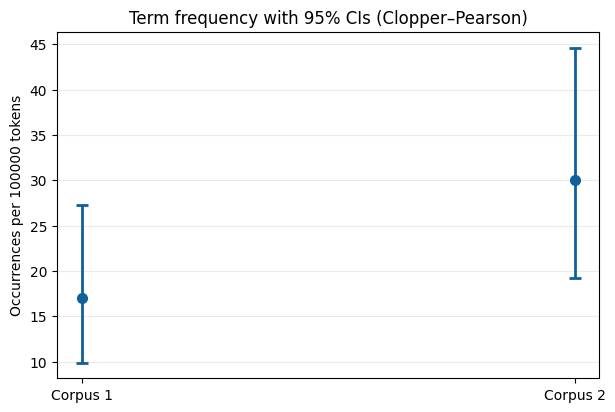

In [77]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Corpus 1", "Corpus 2"]
rates = [p1 * per, p2 * per]
ci_los = [rates[0] - lo1 * per, rates[1] - lo2 * per]
ci_his = [hi1 * per - rates[0], hi2 * per - rates[1]]

x = [0, 1]
ax.errorbar(
    x, rates, yerr=[ci_los, ci_his], fmt="o", color="#0f609b",
    ecolor="#0f609b", elinewidth=2, capsize=4, capthick=2, markersize=7
)
ax.set_xticks(x, labels)
ax.set_ylabel(f"Occurrences per {per} tokens")
ax.set_title("Term frequency with 95% CIs (Clopper–Pearson)")
ax.grid(axis="y", alpha=0.25)

# Annotate counts
for xi, r, k, n in zip(x, rates, [a1, a2], [n1, n2]):
    ax.text(xi, r, f"{k}/{n}", ha="center", va="bottom", fontsize=9, color="#333", xytext=(0, 6))

# p-values box
text = (f"Fisher p = {p_fisher:.3g}\n"
        f"G-test p = {p_g:.3g}\n"
        f"RR = {rr:.3g} (95% CI [{rr_lo:.3g}, {rr_hi:.3g}])")
ax.text(1.02, 0.5, text, transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="#f8fafc", ec="#d5dbe1"),
        va="center")

plt.tight_layout()
plt.show()

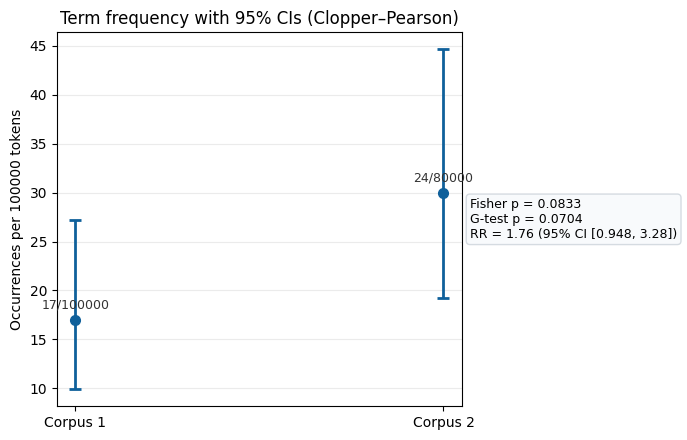

In [79]:
# Cell 4 — Visualization (fixed)
fig, ax = plt.subplots(figsize=(7, 4.5))

labels = ["Corpus 1", "Corpus 2"]
rates = [p1 * per, p2 * per]
ci_los = [rates[0] - lo1 * per, rates[1] - lo2 * per]
ci_his = [hi1 * per - rates[0], hi2 * per - rates[1]]

x = [0, 1]
ax.errorbar(
    x, rates, yerr=[ci_los, ci_his],
    fmt="o", color="#0f609b",
    ecolor="#0f609b", elinewidth=2, capsize=4, capthick=2, markersize=7
)

# Tick labels (compatible with older Matplotlib)
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel(f"Occurrences per {per} tokens")
ax.set_title("Term frequency with 95% CIs (Clopper–Pearson)")
ax.grid(axis="y", alpha=0.25)

# Annotate counts at each point (use annotate, not text)
for xi, r, k, n in zip(x, rates, [a1, a2], [n1, n2]):
    ax.annotate(
        f"{k}/{n}", xy=(xi, r), xytext=(0, 6),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=9, color="#333"
    )

# Side info box (text is fine; no xytext here)
text = (f"Fisher p = {p_fisher:.3g}\n"
        f"G-test p = {p_g:.3g}\n"
        f"RR = {rr:.3g} (95% CI [{rr_lo:.3g}, {rr_hi:.3g}])")
ax.text(
    1.02, 0.5, text, transform=ax.transAxes, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="#f8fafc", ec="#d5dbe1"),
    va="center"
)

plt.tight_layout()
plt.show()